# Descriptor Probing Results Analysis

## Objective
Comprehensive exploratory analysis of RDKit descriptor probing results from cluster training.

We probe **201 RDKit molecular descriptors** using SSL embeddings to understand:
- Which molecular properties are well-encoded in the learned representations
- Performance comparison between Linear and MLP probes
- Descriptor categories that perform best/worst
- Non-linear relationships in the embeddings

## Dataset
- **Training**: 159,271 molecules
- **Test**: 45,185 molecules
- **Embeddings**: 1024-dimensional SSL representations
- **Descriptors**: 201 valid RDKit molecular descriptors

## Probe Models
- **Linear Probe**: 1024→1 (baseline)
- **MLP Probe**: 1024→256→128→1 with ReLU + Dropout(0.2)

## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pickle

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (16, 8)
plt.rcParams['font.size'] = 11

print("✅ Libraries imported successfully")

✅ Libraries imported successfully


## 2. Load Probing Results

In [2]:
# Load Linear probe results
linear_path = Path('../../results/all_descriptors_probing_results_linear.pkl')
with open(linear_path, 'rb') as f:
    linear_results = pickle.load(f)

print(f"✅ Loaded Linear probe results: {len(linear_results)} descriptors")

# Load MLP probe results
mlp_path = Path('../../results/all_descriptors_probing_results_mlp.pkl')
with open(mlp_path, 'rb') as f:
    mlp_results = pickle.load(f)

print(f"✅ Loaded MLP probe results: {len(mlp_results)} descriptors")

# Convert to DataFrames
linear_df = pd.DataFrame([{k: v for k, v in r.items() if k not in ['model', 'scaler']} 
                          for r in linear_results])
mlp_df = pd.DataFrame([{k: v for k, v in r.items() if k not in ['model', 'scaler']} 
                       for r in mlp_results])

# Merge both results
df_results = linear_df.merge(mlp_df, on='descriptor', suffixes=('_linear', '_mlp'))

# Add comparison columns
df_results['r2_best'] = df_results[['r2_linear', 'r2_mlp']].max(axis=1)
df_results['r2_improvement'] = df_results['r2_mlp'] - df_results['r2_linear']
df_results['better_model'] = df_results.apply(
    lambda row: 'MLP' if row['r2_mlp'] > row['r2_linear'] else 
                'Linear' if row['r2_linear'] > row['r2_mlp'] else 'Tie',
    axis=1
)

print(f"\n✅ Combined dataset: {len(df_results)} descriptors")
print(f"   Columns: {df_results.columns.tolist()}")

✅ Loaded Linear probe results: 201 descriptors
✅ Loaded MLP probe results: 201 descriptors

✅ Combined dataset: 201 descriptors
   Columns: ['descriptor', 'r2_linear', 'mae_linear', 'n_train_linear', 'n_test_linear', 'train_mean_linear', 'train_std_linear', 'test_mean_linear', 'test_std_linear', 'r2_mlp', 'mae_mlp', 'n_train_mlp', 'n_test_mlp', 'train_mean_mlp', 'train_std_mlp', 'test_mean_mlp', 'test_std_mlp', 'r2_best', 'r2_improvement', 'better_model']


## 3. Dataset Overview

In [3]:
print("📊 Dataset Information")
print("=" * 70)
print(f"\nTotal descriptors probed: {len(df_results)}")
print(f"Shape: {df_results.shape}")
print(f"\nColumn names:\n{df_results.columns.tolist()}")

print("\n\n📈 Sample of Combined Results:")
print(df_results[['descriptor', 'r2_linear', 'r2_mlp', 'r2_improvement', 'better_model']].head(10))

📊 Dataset Information

Total descriptors probed: 201
Shape: (201, 20)

Column names:
['descriptor', 'r2_linear', 'mae_linear', 'n_train_linear', 'n_test_linear', 'train_mean_linear', 'train_std_linear', 'test_mean_linear', 'test_std_linear', 'r2_mlp', 'mae_mlp', 'n_train_mlp', 'n_test_mlp', 'train_mean_mlp', 'train_std_mlp', 'test_mean_mlp', 'test_std_mlp', 'r2_best', 'r2_improvement', 'better_model']


📈 Sample of Combined Results:
            descriptor  r2_linear    r2_mlp  r2_improvement better_model
0       MaxEStateIndex   0.174937  0.110884       -0.064053       Linear
1       MinEStateIndex   0.005198  0.028214        0.023016          MLP
2    MaxAbsEStateIndex   0.165088  0.118756       -0.046332       Linear
3    MinAbsEStateIndex   0.073738  0.014802       -0.058937       Linear
4                  qed   0.142121  0.128384       -0.013737       Linear
5                MolWt   0.376566  0.516131        0.139565          MLP
6       HeavyAtomMolWt   0.432720  0.501088        0

## 4. Summary Statistics

In [4]:
print("📊 R² Score Comparison: Linear vs MLP")
print("=" * 70)

# Linear statistics
print("\n🔵 Linear Probe:")
print(f"  Median R²: {df_results['r2_linear'].median():.4f}")
print(f"  Mean R²:   {df_results['r2_linear'].mean():.4f}")
print(f"  Std R²:    {df_results['r2_linear'].std():.4f}")
print(f"  Min R²:    {df_results['r2_linear'].min():.4f}")
print(f"  Max R²:    {df_results['r2_linear'].max():.4f}")
print(f"  Positive R² count: {(df_results['r2_linear'] > 0).sum()}/{len(df_results)}")

# MLP statistics
print("\n🟢 MLP Probe:")
print(f"  Median R²: {df_results['r2_mlp'].median():.4f}")
print(f"  Mean R²:   {df_results['r2_mlp'].mean():.4f}")
print(f"  Std R²:    {df_results['r2_mlp'].std():.4f}")
print(f"  Min R²:    {df_results['r2_mlp'].min():.4f}")
print(f"  Max R²:    {df_results['r2_mlp'].max():.4f}")
print(f"  Positive R² count: {(df_results['r2_mlp'] > 0).sum()}/{len(df_results)}")

# Model comparison
print("\n⚖️ Model Comparison:")
print(f"  MLP better: {(df_results['better_model'] == 'MLP').sum()} descriptors")
print(f"  Linear better: {(df_results['better_model'] == 'Linear').sum()} descriptors")
print(f"  Tied: {(df_results['better_model'] == 'Tie').sum()} descriptors")

# Improvement statistics
print("\n📈 R² Improvement (MLP - Linear):")
print(f"  Mean improvement: {df_results['r2_improvement'].mean():.4f}")
print(f"  Median improvement: {df_results['r2_improvement'].median():.4f}")
print(f"  Std: {df_results['r2_improvement'].std():.4f}")
print(f"  Max improvement: {df_results['r2_improvement'].max():.4f}")
print(f"  Max decline: {df_results['r2_improvement'].min():.4f}")

📊 R² Score Comparison: Linear vs MLP

🔵 Linear Probe:
  Median R²: 0.0547
  Mean R²:   0.0070
  Std R²:    0.5012
  Min R²:    -4.8065
  Max R²:    0.4456
  Positive R² count: 127/201

🟢 MLP Probe:
  Median R²: 0.0735
  Mean R²:   0.1028
  Std R²:    0.2533
  Min R²:    -1.9280
  Max R²:    0.5587
  Positive R² count: 132/201

⚖️ Model Comparison:
  MLP better: 118 descriptors
  Linear better: 80 descriptors
  Tied: 3 descriptors

📈 R² Improvement (MLP - Linear):
  Mean improvement: 0.0959
  Median improvement: 0.0261
  Std: 0.4412
  Max improvement: 4.8533
  Max decline: -0.5758


## 5. R² Distribution Analysis

/var/folders/21/cp9j844d6q74kpp18myp0wxr0000gn/T/ipykernel_29783/4278985483.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1, 0].boxplot(box_data, labels=['Linear', 'MLP'], patch_artist=True,


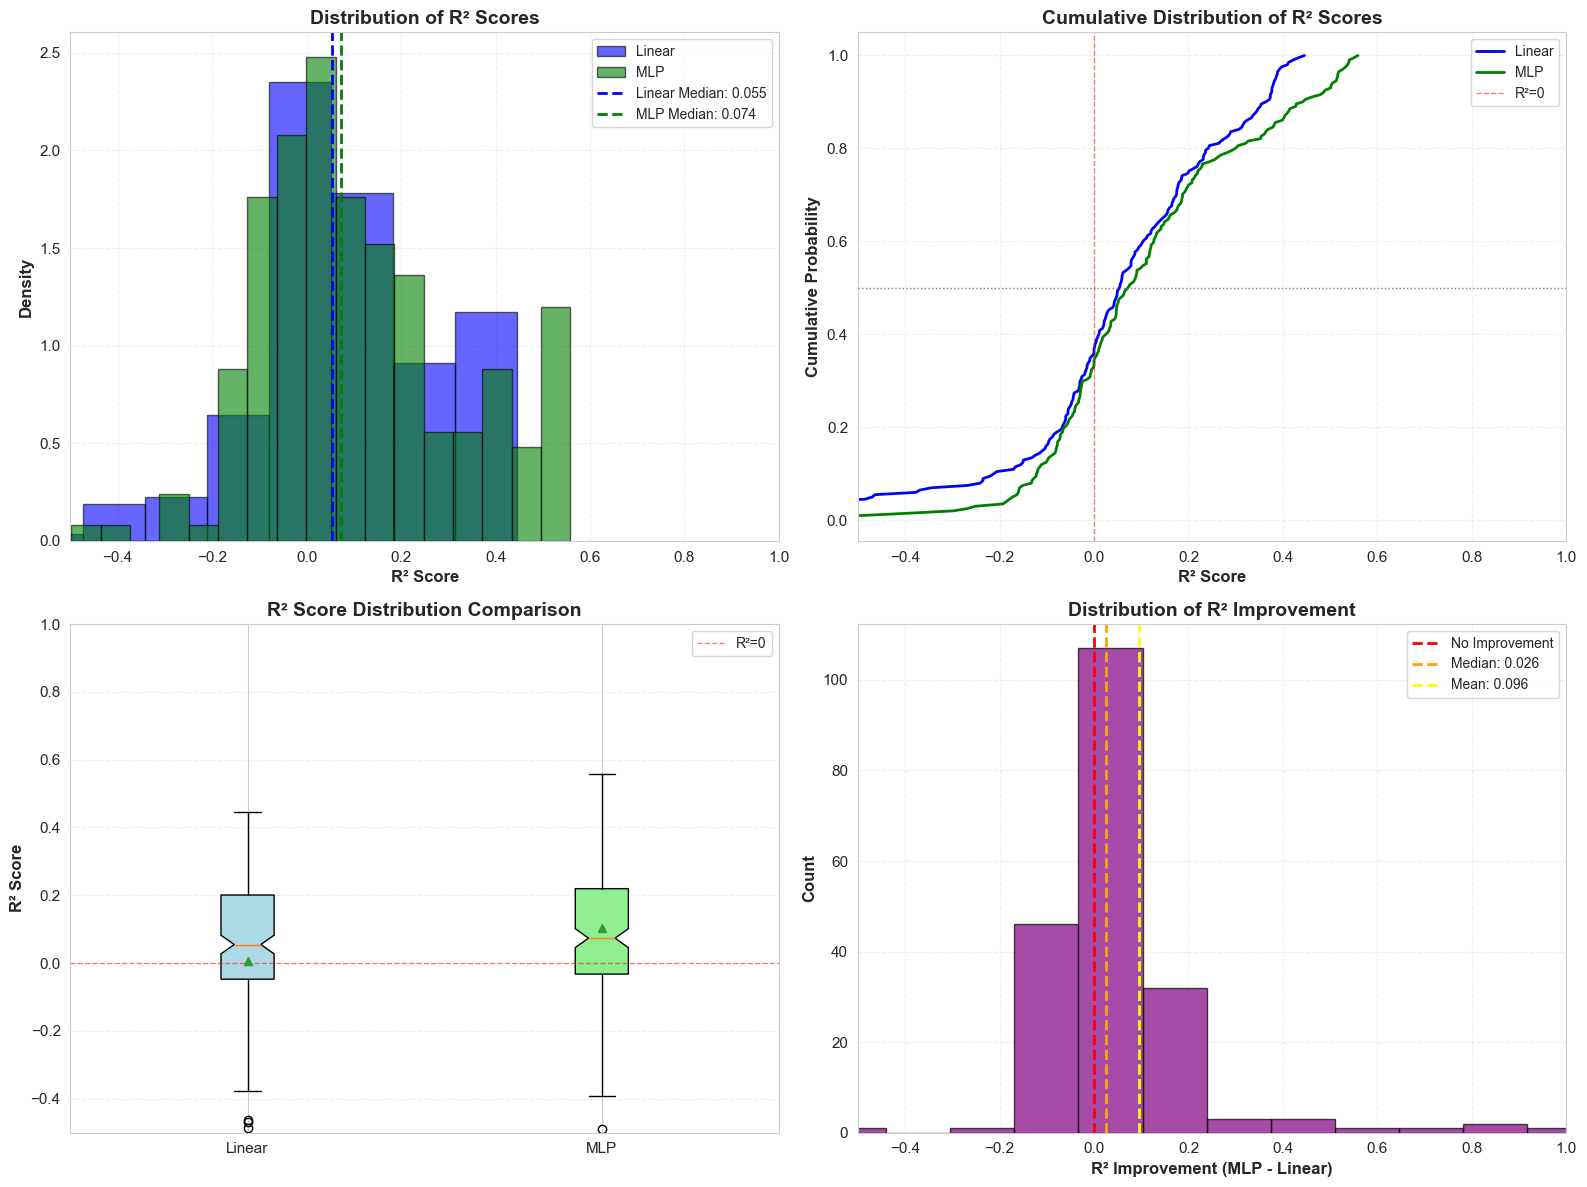

✅ R² Distribution plots generated


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Histograms with KDE
axes[0, 0].hist(df_results['r2_linear'], bins=40, alpha=0.6, color='blue', 
                edgecolor='black', label='Linear', density=True)
axes[0, 0].hist(df_results['r2_mlp'], bins=40, alpha=0.6, color='green', 
                edgecolor='black', label='MLP', density=True)
axes[0, 0].axvline(df_results['r2_linear'].median(), color='blue', 
                   linestyle='--', linewidth=2, label=f'Linear Median: {df_results["r2_linear"].median():.3f}')
axes[0, 0].axvline(df_results['r2_mlp'].median(), color='green', 
                   linestyle='--', linewidth=2, label=f'MLP Median: {df_results["r2_mlp"].median():.3f}')
axes[0, 0].set_xlabel('R² Score', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Density', fontsize=12, fontweight='bold')
axes[0, 0].set_title('Distribution of R² Scores', fontsize=14, fontweight='bold')
axes[0, 0].set_xlim(-0.5, 1.0)
axes[0, 0].legend(fontsize=10)
axes[0, 0].grid(alpha=0.3, linestyle='--')

# 2. Cumulative distribution
r2_linear_sorted = np.sort(df_results['r2_linear'])
r2_mlp_sorted = np.sort(df_results['r2_mlp'])
cumulative_linear = np.arange(1, len(r2_linear_sorted) + 1) / len(r2_linear_sorted)
cumulative_mlp = np.arange(1, len(r2_mlp_sorted) + 1) / len(r2_mlp_sorted)

axes[0, 1].plot(r2_linear_sorted, cumulative_linear, color='blue', linewidth=2, label='Linear')
axes[0, 1].plot(r2_mlp_sorted, cumulative_mlp, color='green', linewidth=2, label='MLP')
axes[0, 1].axhline(0.5, color='gray', linestyle=':', linewidth=1)
axes[0, 1].axvline(0, color='red', linestyle='--', linewidth=1, alpha=0.5, label='R²=0')
axes[0, 1].set_xlabel('R² Score', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Cumulative Probability', fontsize=12, fontweight='bold')
axes[0, 1].set_title('Cumulative Distribution of R² Scores', fontsize=14, fontweight='bold')
axes[0, 1].set_xlim(-0.5, 1.0)
axes[0, 1].legend(fontsize=10)
axes[0, 1].grid(alpha=0.3, linestyle='--')

# 3. Box plots
box_data = [df_results['r2_linear'], df_results['r2_mlp']]
bp = axes[1, 0].boxplot(box_data, labels=['Linear', 'MLP'], patch_artist=True,
                        notch=True, showmeans=True)
bp['boxes'][0].set_facecolor('lightblue')
bp['boxes'][1].set_facecolor('lightgreen')
axes[1, 0].axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.5, label='R²=0')
axes[1, 0].set_ylabel('R² Score', fontsize=12, fontweight='bold')
axes[1, 0].set_title('R² Score Distribution Comparison', fontsize=14, fontweight='bold')
axes[1, 0].set_ylim(-0.5, 1.0)
axes[1, 0].grid(axis='y', alpha=0.3, linestyle='--')
axes[1, 0].legend(fontsize=10)

# 4. Improvement histogram
axes[1, 1].hist(df_results['r2_improvement'], bins=40, color='purple', 
                edgecolor='black', alpha=0.7)
axes[1, 1].axvline(0, color='red', linestyle='--', linewidth=2, label='No Improvement')
axes[1, 1].axvline(df_results['r2_improvement'].median(), color='orange', 
                   linestyle='--', linewidth=2, label=f'Median: {df_results["r2_improvement"].median():.3f}')
axes[1, 1].axvline(df_results['r2_improvement'].mean(), color='yellow', 
                   linestyle='--', linewidth=2, label=f'Mean: {df_results["r2_improvement"].mean():.3f}')
axes[1, 1].set_xlabel('R² Improvement (MLP - Linear)', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Count', fontsize=12, fontweight='bold')
axes[1, 1].set_title('Distribution of R² Improvement', fontsize=14, fontweight='bold')
axes[1, 1].set_xlim(-0.5, 1.0)
axes[1, 1].legend(fontsize=10)
axes[1, 1].grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

print("✅ R² Distribution plots generated")

## 6. Linear vs MLP Comparison

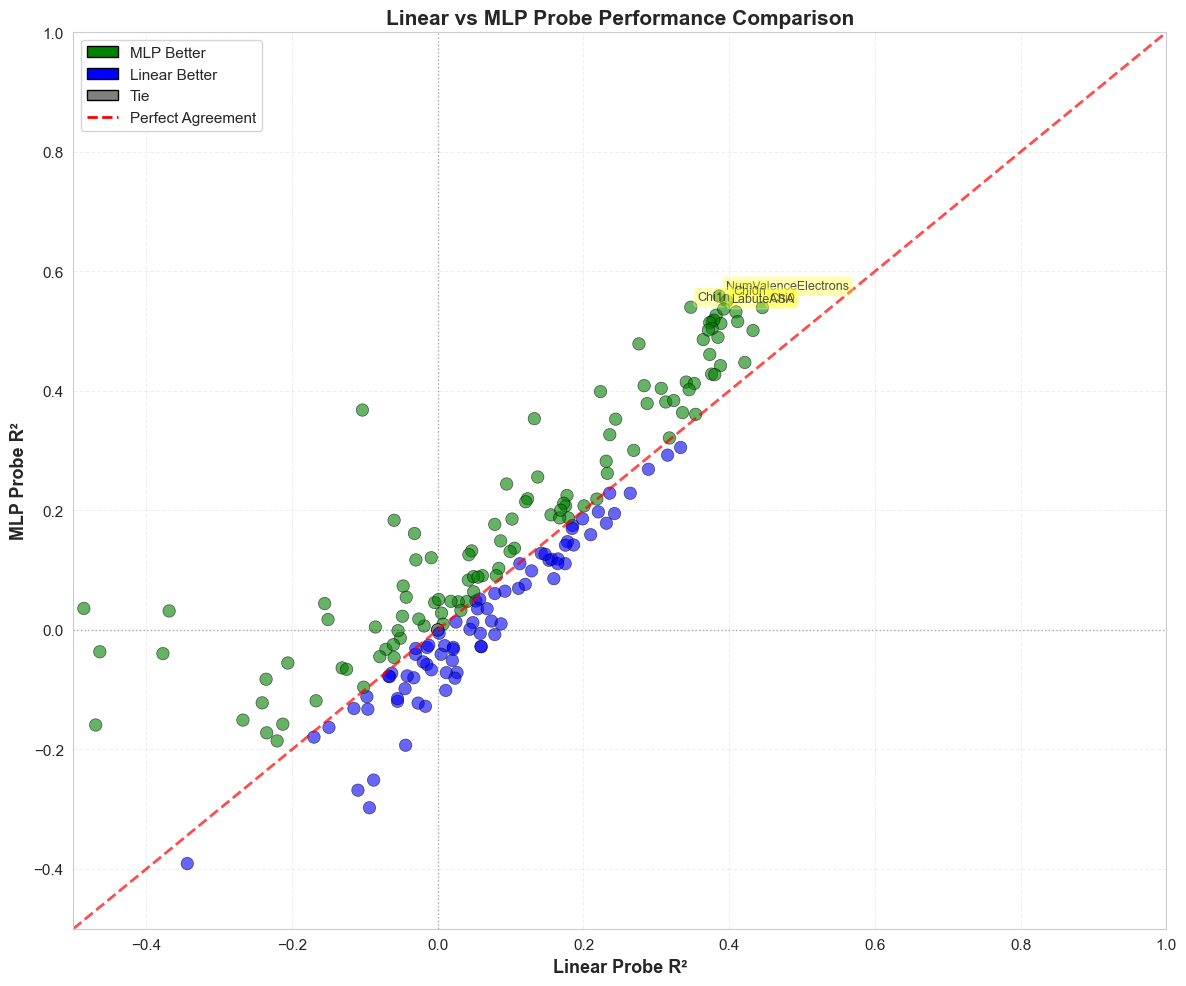

✅ Linear vs MLP scatter plot generated

Top 5 overall performers (by best R²):
         descriptor  r2_linear   r2_mlp better_model
NumValenceElectrons   0.386217 0.558695          MLP
              Chi0n   0.396640 0.550203          MLP
              Chi1n   0.347323 0.539995          MLP
               Chi0   0.445562 0.539362          MLP
          LabuteASA   0.392469 0.536900          MLP


In [6]:
fig, ax = plt.subplots(figsize=(12, 10))

# Color code by which model is better
colors = df_results['better_model'].map({'MLP': 'green', 'Linear': 'blue', 'Tie': 'gray'})

# Scatter plot
scatter = ax.scatter(df_results['r2_linear'], df_results['r2_mlp'], 
                     c=colors, alpha=0.6, s=80, edgecolors='black', linewidth=0.5)

# Diagonal line (perfect agreement)
ax.plot([-0.5, 1.0], [-0.5, 1.0], 'r--', linewidth=2, label='Perfect Agreement', alpha=0.7)

# Reference lines at R²=0
ax.axhline(0, color='black', linestyle=':', linewidth=1, alpha=0.3)
ax.axvline(0, color='black', linestyle=':', linewidth=1, alpha=0.3)

# Annotate top performers
top_n = 5
top_descriptors = df_results.nlargest(top_n, 'r2_best')
for _, row in top_descriptors.iterrows():
    ax.annotate(row['descriptor'], 
                xy=(row['r2_linear'], row['r2_mlp']),
                xytext=(5, 5), textcoords='offset points',
                fontsize=9, alpha=0.8,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.3))

ax.set_xlabel('Linear Probe R²', fontsize=13, fontweight='bold')
ax.set_ylabel('MLP Probe R²', fontsize=13, fontweight='bold')
ax.set_title('Linear vs MLP Probe Performance Comparison', fontsize=15, fontweight='bold')
ax.set_xlim(-0.5, 1.0)
ax.set_ylim(-0.5, 1.0)
ax.grid(alpha=0.3, linestyle='--')

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='green', edgecolor='black', label='MLP Better'),
    Patch(facecolor='blue', edgecolor='black', label='Linear Better'),
    Patch(facecolor='gray', edgecolor='black', label='Tie'),
    plt.Line2D([0], [0], color='r', linestyle='--', linewidth=2, label='Perfect Agreement')
]
ax.legend(handles=legend_elements, fontsize=11, loc='upper left')

plt.tight_layout()
plt.show()

print("✅ Linear vs MLP scatter plot generated")
print(f"\nTop 5 overall performers (by best R²):")
print(top_descriptors[['descriptor', 'r2_linear', 'r2_mlp', 'better_model']].to_string(index=False))

## 7. Top and Bottom Performers

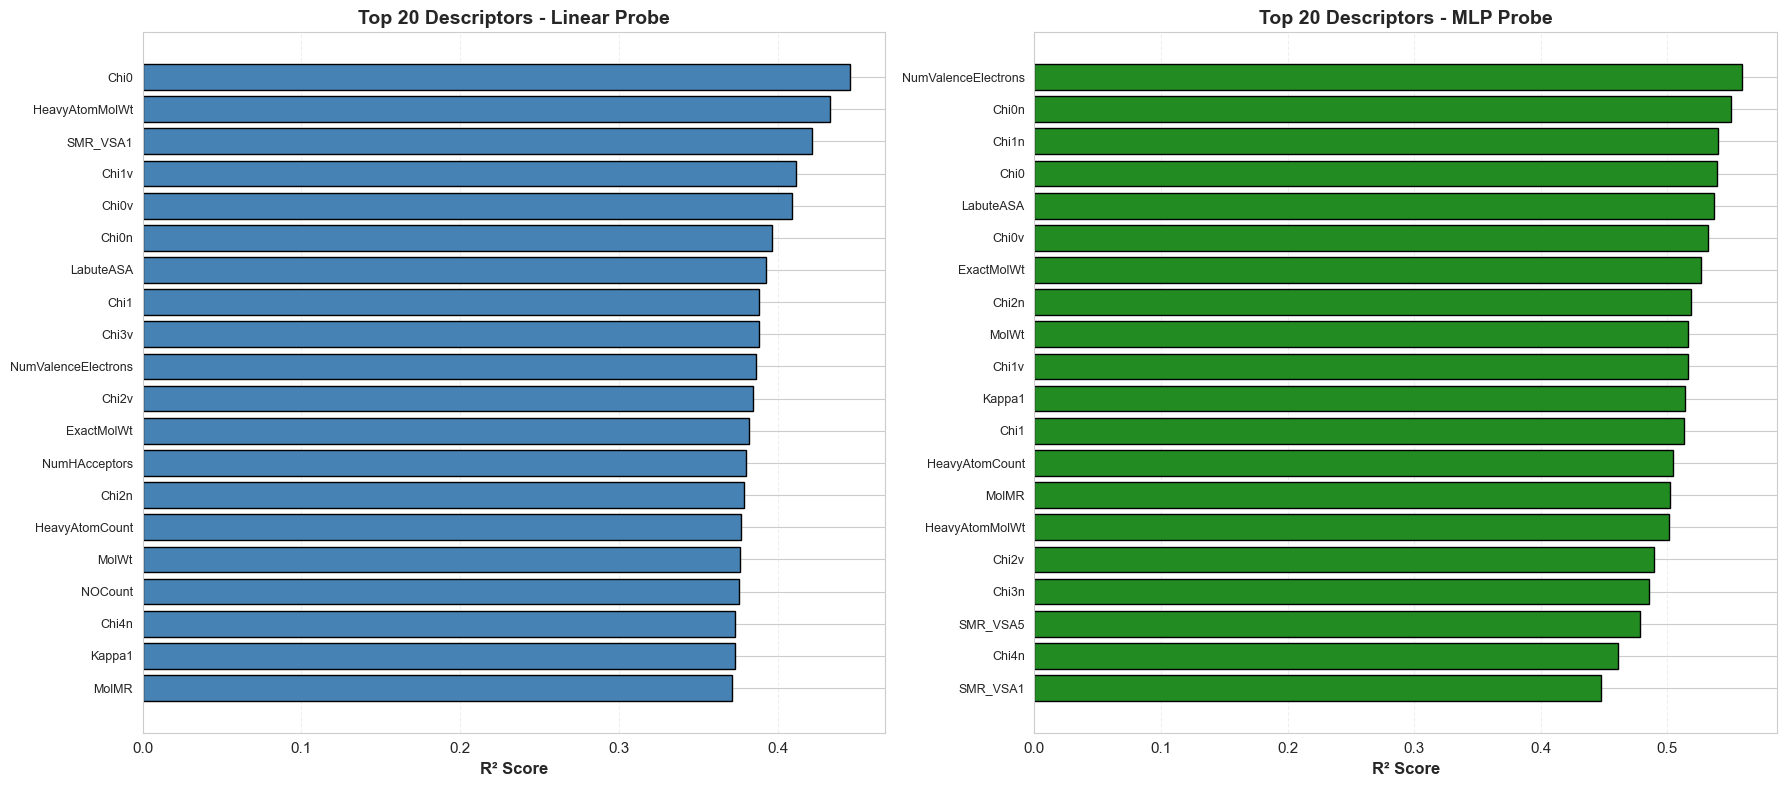

✅ Top 20 descriptors plots generated


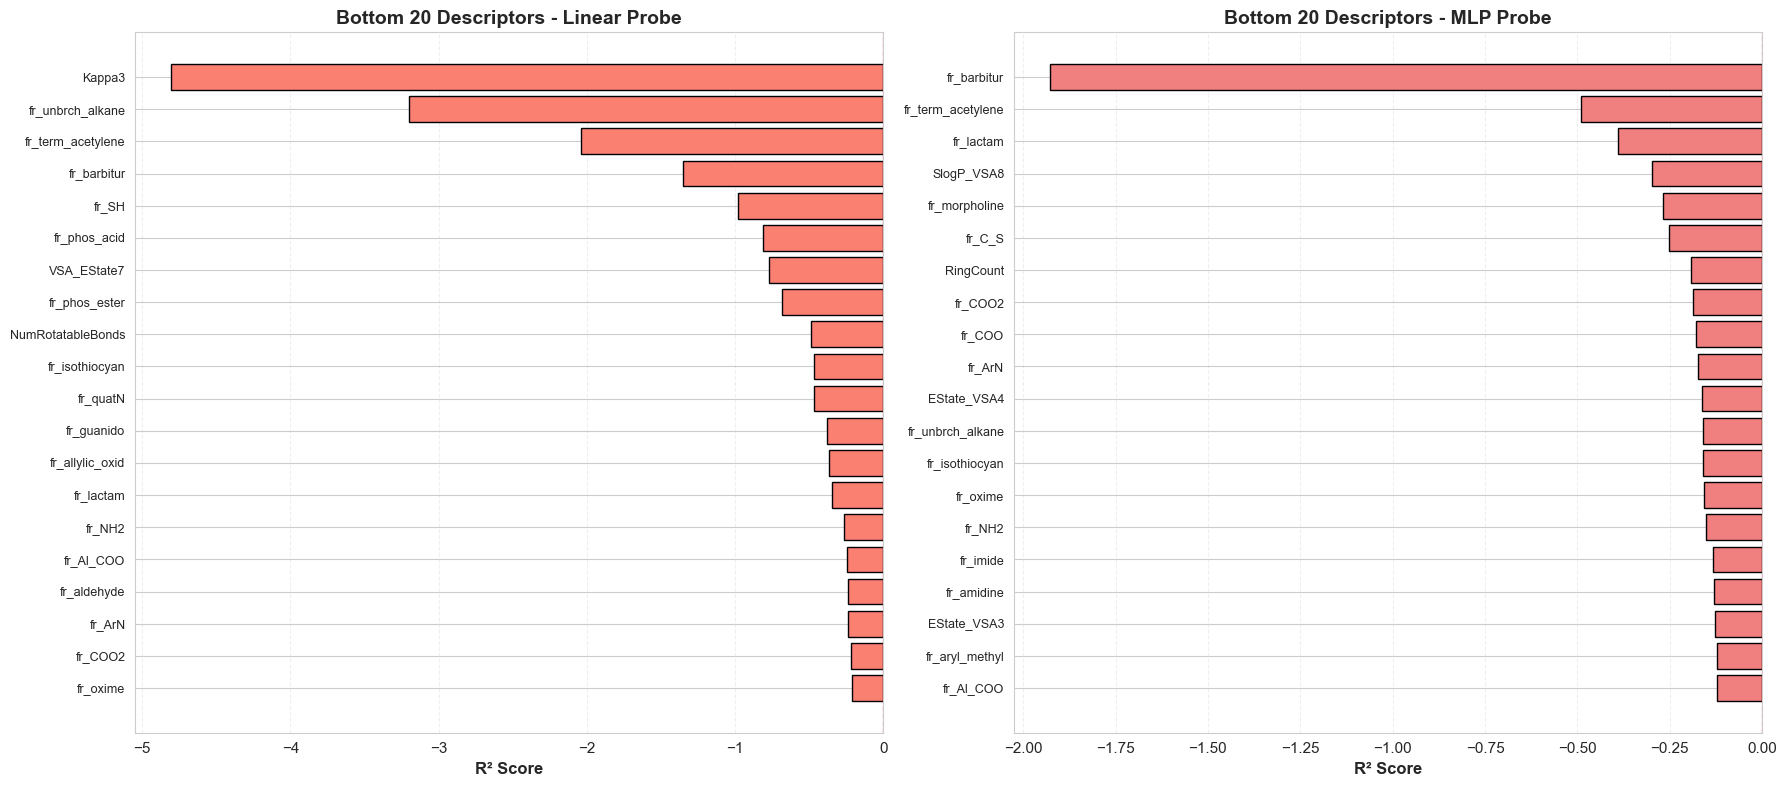

✅ Bottom 20 descriptors plots generated


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Top 20 Linear
top20_linear = df_results.nlargest(20, 'r2_linear')[['descriptor', 'r2_linear']].sort_values('r2_linear')
axes[0].barh(top20_linear['descriptor'], top20_linear['r2_linear'], color='steelblue', edgecolor='black')
axes[0].set_xlabel('R² Score', fontsize=12, fontweight='bold')
axes[0].set_title('Top 20 Descriptors - Linear Probe', fontsize=14, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3, linestyle='--')
axes[0].tick_params(axis='y', labelsize=9)

# Top 20 MLP
top20_mlp = df_results.nlargest(20, 'r2_mlp')[['descriptor', 'r2_mlp']].sort_values('r2_mlp')
axes[1].barh(top20_mlp['descriptor'], top20_mlp['r2_mlp'], color='forestgreen', edgecolor='black')
axes[1].set_xlabel('R² Score', fontsize=12, fontweight='bold')
axes[1].set_title('Top 20 Descriptors - MLP Probe', fontsize=14, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3, linestyle='--')
axes[1].tick_params(axis='y', labelsize=9)

plt.tight_layout()
plt.show()

print("✅ Top 20 descriptors plots generated")

# Second figure: Bottom 20 performers
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Bottom 20 Linear
bottom20_linear = df_results.nsmallest(20, 'r2_linear')[['descriptor', 'r2_linear']].sort_values('r2_linear', ascending=False)
axes[0].barh(bottom20_linear['descriptor'], bottom20_linear['r2_linear'], color='salmon', edgecolor='black')
axes[0].set_xlabel('R² Score', fontsize=12, fontweight='bold')
axes[0].set_title('Bottom 20 Descriptors - Linear Probe', fontsize=14, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3, linestyle='--')
axes[0].axvline(0, color='red', linestyle='--', linewidth=1, alpha=0.5)
axes[0].tick_params(axis='y', labelsize=9)

# Bottom 20 MLP
bottom20_mlp = df_results.nsmallest(20, 'r2_mlp')[['descriptor', 'r2_mlp']].sort_values('r2_mlp', ascending=False)
axes[1].barh(bottom20_mlp['descriptor'], bottom20_mlp['r2_mlp'], color='lightcoral', edgecolor='black')
axes[1].set_xlabel('R² Score', fontsize=12, fontweight='bold')
axes[1].set_title('Bottom 20 Descriptors - MLP Probe', fontsize=14, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3, linestyle='--')
axes[1].axvline(0, color='red', linestyle='--', linewidth=1, alpha=0.5)
axes[1].tick_params(axis='y', labelsize=9)

plt.tight_layout()
plt.show()

print("✅ Bottom 20 descriptors plots generated")

## 8. MLP Improvement Analysis

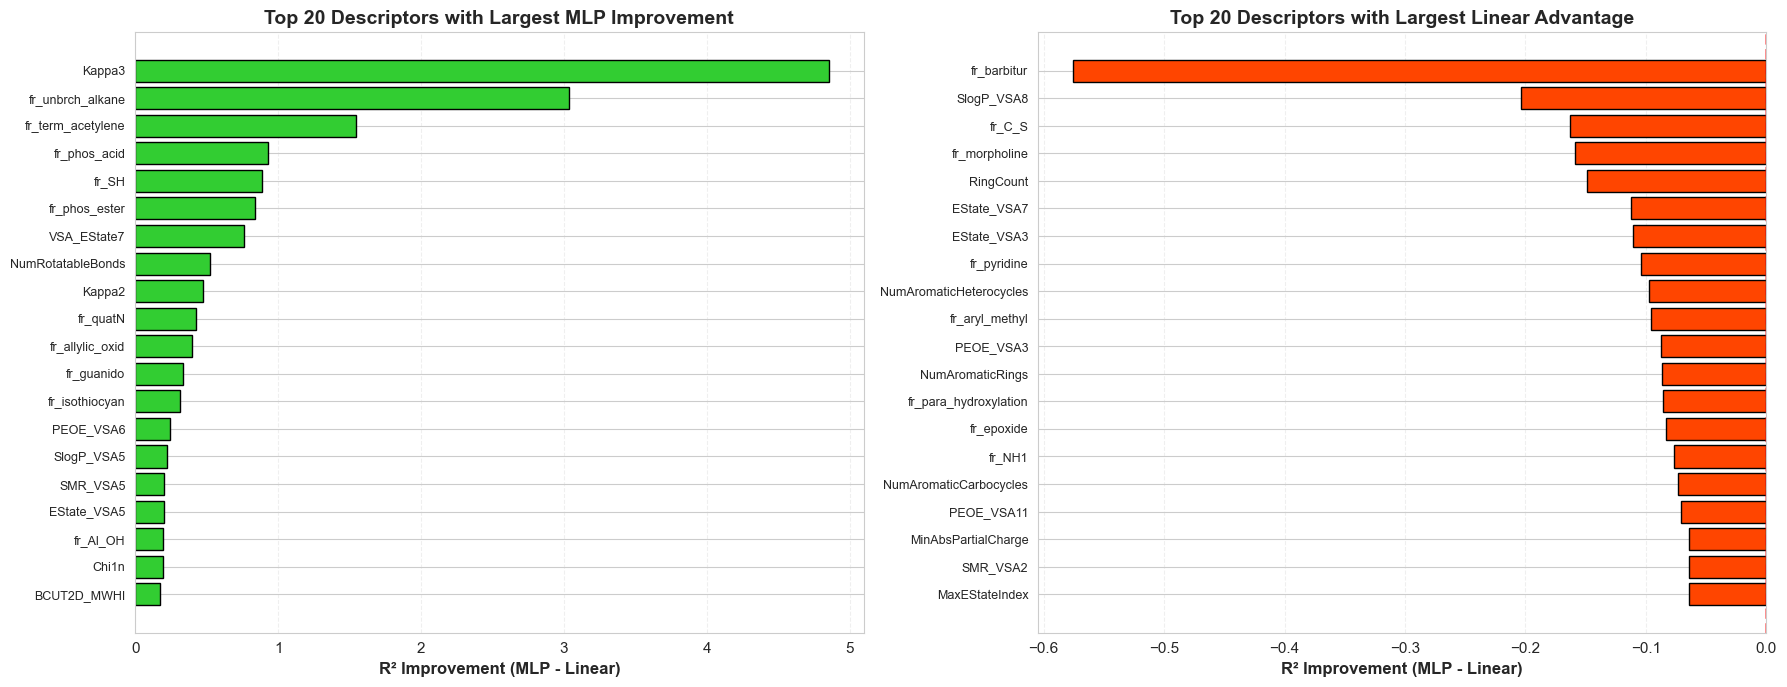

✅ MLP improvement analysis plots generated

📈 Top 5 MLP improvements:
       descriptor  r2_linear    r2_mlp  r2_improvement
            fr_SH  -0.978001 -0.089247        0.888754
     fr_phos_acid  -0.811132  0.120518        0.931650
fr_term_acetylene  -2.037137 -0.489977        1.547160
 fr_unbrch_alkane  -3.197744 -0.160004        3.037741
           Kappa3  -4.806458  0.046890        4.853348

📉 Top 5 Linear advantages:
            descriptor  r2_linear    r2_mlp  r2_improvement
        MaxEStateIndex   0.174937  0.110884       -0.064053
              SMR_VSA2  -0.055192 -0.119405       -0.064213
   MinAbsPartialCharge   0.058426 -0.005812       -0.064238
            PEOE_VSA11   0.020054 -0.051108       -0.071163
NumAromaticCarbocycles   0.159360  0.085737       -0.073622


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Top 20 improvements (where MLP significantly outperforms Linear)
top_improvements = df_results.nlargest(20, 'r2_improvement')[['descriptor', 'r2_improvement', 'r2_linear', 'r2_mlp']].sort_values('r2_improvement')

axes[0].barh(top_improvements['descriptor'], top_improvements['r2_improvement'], 
             color='limegreen', edgecolor='black')
axes[0].set_xlabel('R² Improvement (MLP - Linear)', fontsize=12, fontweight='bold')
axes[0].set_title('Top 20 Descriptors with Largest MLP Improvement', fontsize=14, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3, linestyle='--')
axes[0].tick_params(axis='y', labelsize=9)

# Top 20 declines (where Linear outperforms MLP)
top_declines = df_results.nsmallest(20, 'r2_improvement')[['descriptor', 'r2_improvement', 'r2_linear', 'r2_mlp']].sort_values('r2_improvement', ascending=False)

axes[1].barh(top_declines['descriptor'], top_declines['r2_improvement'], 
             color='orangered', edgecolor='black')
axes[1].set_xlabel('R² Improvement (MLP - Linear)', fontsize=12, fontweight='bold')
axes[1].set_title('Top 20 Descriptors with Largest Linear Advantage', fontsize=14, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3, linestyle='--')
axes[1].axvline(0, color='red', linestyle='--', linewidth=2, alpha=0.5)
axes[1].tick_params(axis='y', labelsize=9)

plt.tight_layout()
plt.show()

print("✅ MLP improvement analysis plots generated")
print("\n📈 Top 5 MLP improvements:")
print(top_improvements.tail(5)[['descriptor', 'r2_linear', 'r2_mlp', 'r2_improvement']].to_string(index=False))
print("\n📉 Top 5 Linear advantages:")
print(top_declines.head(5)[['descriptor', 'r2_linear', 'r2_mlp', 'r2_improvement']].to_string(index=False))

## 9. Descriptor Category Analysis

Let's group descriptors by type to understand which categories are well-encoded in the SSL embeddings.

📊 Descriptor Category Statistics:
                 r2_linear                        r2_mlp                  \
                      mean  median     std count    mean  median     std   
category                                                                   
Connectivity        0.0039  0.3789  1.3370    15  0.4614  0.5128  0.1260   
Counts/Fractions    0.1171  0.1755  0.2839     7  0.2304  0.1925  0.1337   
Electronic          0.1468  0.0584  0.2097     3  0.1996  0.0458  0.3121   
H-Bonding           0.1685  0.1685  0.2994     2  0.2410  0.2410  0.2633   
Lipophilicity       0.0608  0.0524  0.1416     7  0.0530  0.0517  0.1817   
Molecular Weight    0.3971  0.3820  0.0310     3  0.5146  0.5161  0.0128   
Other              -0.0844 -0.0123  0.4525   101  0.0105  0.0000  0.2573   
Polar Surface       0.3527  0.3527  0.0563     2  0.4592  0.4592  0.1099   
Ring/Aromatic       0.1071  0.1093  0.1139     6  0.0510  0.0290  0.1844   
Surface Area        0.0965  0.1053  0.1741    55  0.12

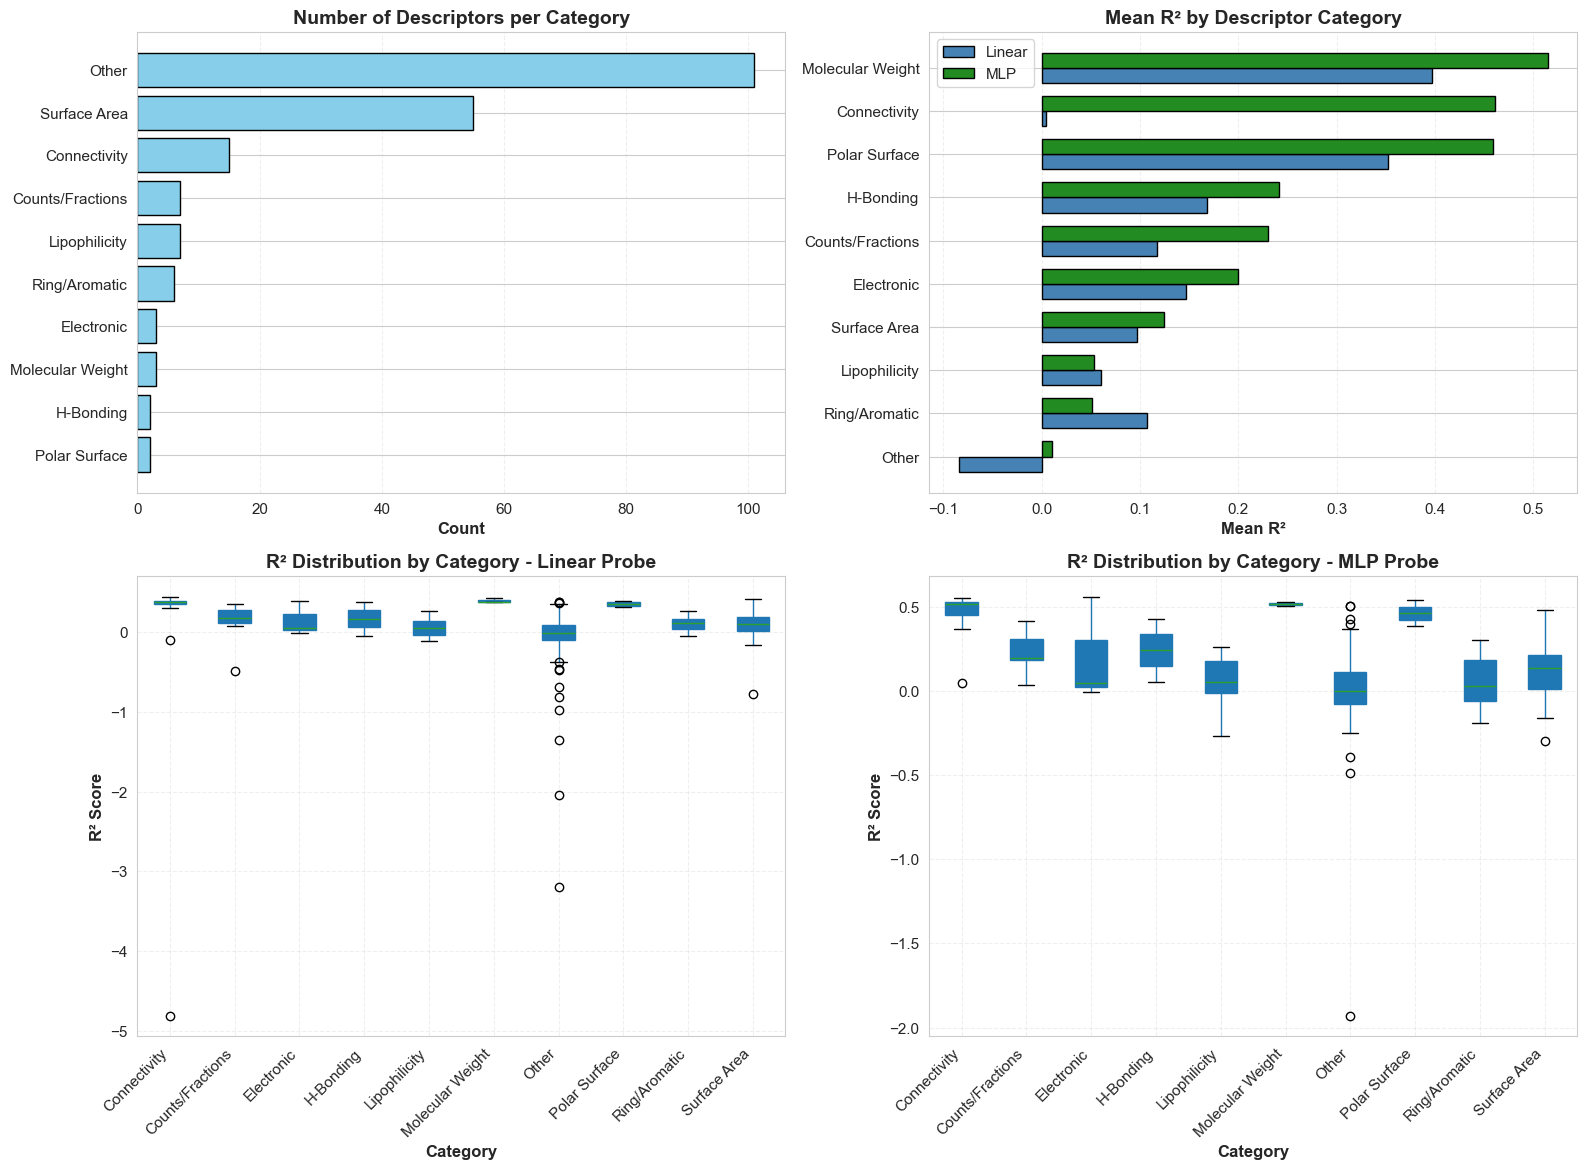


✅ Category analysis plots generated


In [16]:
# Categorize descriptors by common prefixes/patterns
def categorize_descriptor(desc_name):
    """Categorize descriptors by type based on naming patterns."""
    desc_name = desc_name.lower()
    
    if 'chi' in desc_name or 'kappa' in desc_name:
        return 'Connectivity'
    elif 'vsa' in desc_name or 'peoe' in desc_name or 'smr' in desc_name:
        return 'Surface Area'
    elif 'logp' in desc_name or 'mor' in desc_name:
        return 'Lipophilicity'
    elif 'tpsa' in desc_name or 'labute' in desc_name:
        return 'Polar Surface'
    elif 'charge' in desc_name or 'valence' in desc_name:
        return 'Electronic'
    elif 'hba' in desc_name or 'hbd' in desc_name or 'donor' in desc_name or 'acceptor' in desc_name:
        return 'H-Bonding'
    elif 'ring' in desc_name or 'aromatic' in desc_name:
        return 'Ring/Aromatic'
    elif 'mol_wt' in desc_name or 'molwt' in desc_name or 'exactmolwt' in desc_name:
        return 'Molecular Weight'
    elif 'frac' in desc_name or 'num' in desc_name:
        return 'Counts/Fractions'
    else:
        return 'Other'

df_results['category'] = df_results['descriptor'].apply(categorize_descriptor)

# Calculate category statistics
category_stats = df_results.groupby('category').agg({
    'r2_linear': ['mean', 'median', 'std', 'count'],
    'r2_mlp': ['mean', 'median', 'std'],
    'r2_improvement': ['mean', 'median']
}).round(4)

print("📊 Descriptor Category Statistics:")
print("=" * 90)
print(category_stats)

# Visualize category performance
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Category counts
category_counts = df_results['category'].value_counts().sort_values()
axes[0, 0].barh(category_counts.index, category_counts.values, color='skyblue', edgecolor='black')
axes[0, 0].set_xlabel('Count', fontsize=12, fontweight='bold')
axes[0, 0].set_title('Number of Descriptors per Category', fontsize=14, fontweight='bold')
axes[0, 0].grid(axis='x', alpha=0.3, linestyle='--')

# Mean R² by category
category_means = df_results.groupby('category')[['r2_linear', 'r2_mlp']].mean().sort_values('r2_mlp')
x = np.arange(len(category_means))
width = 0.35

axes[0, 1].barh(x - width/2, category_means['r2_linear'], width, label='Linear', 
                color='steelblue', edgecolor='black')
axes[0, 1].barh(x + width/2, category_means['r2_mlp'], width, label='MLP', 
                color='forestgreen', edgecolor='black')
axes[0, 1].set_yticks(x)
axes[0, 1].set_yticklabels(category_means.index)
axes[0, 1].set_xlabel('Mean R²', fontsize=12, fontweight='bold')
axes[0, 1].set_title('Mean R² by Descriptor Category', fontsize=14, fontweight='bold')
axes[0, 1].legend(fontsize=11)
axes[0, 1].grid(axis='x', alpha=0.3, linestyle='--')

# Box plot by category - Linear
df_results.boxplot(column='r2_linear', by='category', ax=axes[1, 0], patch_artist=True)
axes[1, 0].set_xlabel('Category', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('R² Score', fontsize=12, fontweight='bold')
axes[1, 0].set_title('R² Distribution by Category - Linear Probe', fontsize=14, fontweight='bold')
axes[1, 0].get_figure().suptitle('')  # Remove default title
plt.setp(axes[1, 0].xaxis.get_majorticklabels(), rotation=45, ha='right')
axes[1, 0].grid(alpha=0.3, linestyle='--')

# Box plot by category - MLP
df_results.boxplot(column='r2_mlp', by='category', ax=axes[1, 1], patch_artist=True)
axes[1, 1].set_xlabel('Category', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('R² Score', fontsize=12, fontweight='bold')
axes[1, 1].set_title('R² Distribution by Category - MLP Probe', fontsize=14, fontweight='bold')
axes[1, 1].get_figure().suptitle('')  # Remove default title
plt.setp(axes[1, 1].xaxis.get_majorticklabels(), rotation=45, ha='right')
axes[1, 1].grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

print("\n✅ Category analysis plots generated")

## 10. Correlation Analysis

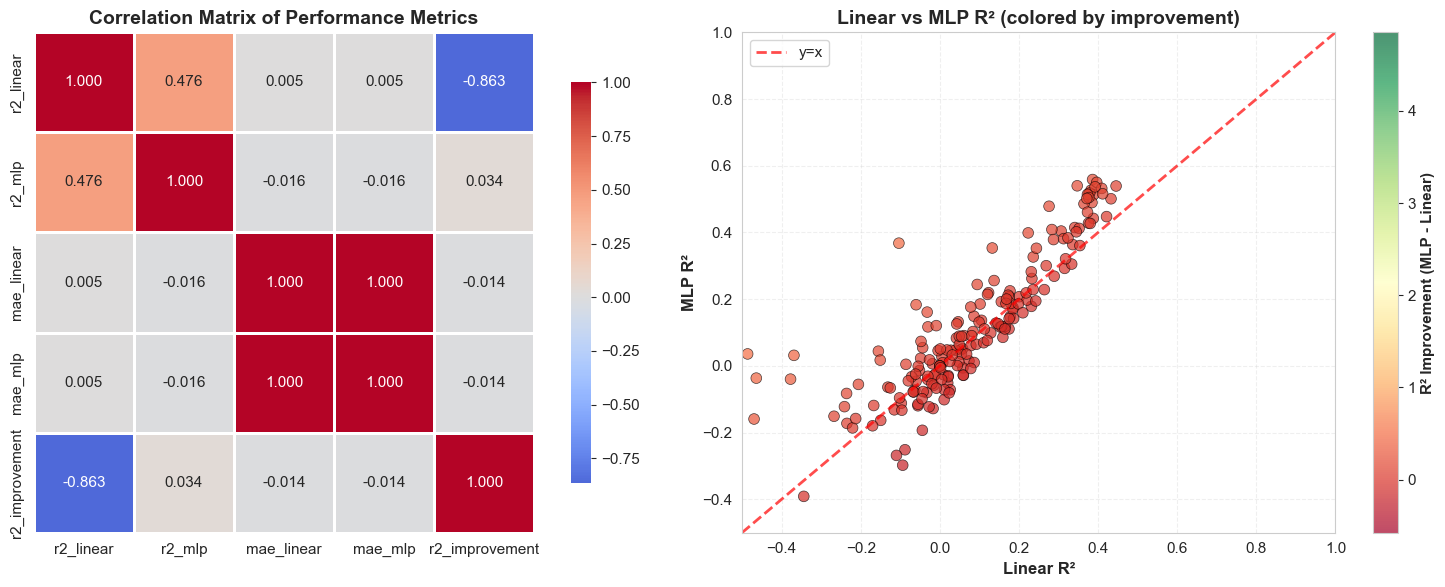

📊 Correlation between Linear and MLP R²:
   Pearson correlation: 0.4756
   Spearman correlation: 0.8725

✅ Correlation analysis plots generated


In [18]:
# Select numeric columns for correlation
corr_cols = ['r2_linear', 'r2_mlp', 'mae_linear', 'mae_mlp', 'r2_improvement']
corr_matrix = df_results[corr_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Full correlation heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8},
            fmt='.3f', ax=axes[0])
axes[0].set_title('Correlation Matrix of Performance Metrics', fontsize=14, fontweight='bold')

# Scatter: Linear R² vs MLP R² (colored by improvement)
scatter = axes[1].scatter(df_results['r2_linear'], df_results['r2_mlp'],
                         c=df_results['r2_improvement'], cmap='RdYlGn',
                         s=60, alpha=0.7, edgecolors='black', linewidth=0.5)
axes[1].plot([-0.5, 1.0], [-0.5, 1.0], 'r--', linewidth=2, alpha=0.7, label='y=x')
axes[1].set_xlabel('Linear R²', fontsize=12, fontweight='bold')
axes[1].set_ylabel('MLP R²', fontsize=12, fontweight='bold')
axes[1].set_title('Linear vs MLP R² (colored by improvement)', fontsize=14, fontweight='bold')
axes[1].set_xlim(-0.5, 1.0)
axes[1].set_ylim(-0.5, 1.0)
axes[1].grid(alpha=0.3, linestyle='--')
axes[1].legend(fontsize=11)

cbar = plt.colorbar(scatter, ax=axes[1])
cbar.set_label('R² Improvement (MLP - Linear)', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# Correlation statistics
print("📊 Correlation between Linear and MLP R²:")
print(f"   Pearson correlation: {df_results['r2_linear'].corr(df_results['r2_mlp']):.4f}")
print(f"   Spearman correlation: {df_results['r2_linear'].corr(df_results['r2_mlp'], method='spearman'):.4f}")

print("\n✅ Correlation analysis plots generated")

## 11. Key Findings Summary

In [19]:
print("=" * 80)
print("🔬 KEY FINDINGS FROM DESCRIPTOR PROBING ANALYSIS")
print("=" * 80)

print("\n1️⃣ OVERALL PERFORMANCE:")
print(f"   • Total descriptors probed: {len(df_results)}")
print(f"   • MLP median R²: {df_results['r2_mlp'].median():.4f} vs Linear: {df_results['r2_linear'].median():.4f}")
print(f"   • MLP mean R²: {df_results['r2_mlp'].mean():.4f} vs Linear: {df_results['r2_linear'].mean():.4f}")
print(f"   • MLP wins in {(df_results['better_model'] == 'MLP').sum()}/{len(df_results)} descriptors")

print("\n2️⃣ TOP PERFORMING DESCRIPTORS:")
top5 = df_results.nlargest(5, 'r2_best')
for i, (_, row) in enumerate(top5.iterrows(), 1):
    print(f"   {i}. {row['descriptor']}: "
          f"Linear={row['r2_linear']:.4f}, MLP={row['r2_mlp']:.4f} "
          f"(Best: {row['better_model']})")

print("\n3️⃣ WORST PERFORMING DESCRIPTORS:")
bottom5 = df_results.nsmallest(5, 'r2_best')
for i, (_, row) in enumerate(bottom5.iterrows(), 1):
    print(f"   {i}. {row['descriptor']}: "
          f"Linear={row['r2_linear']:.4f}, MLP={row['r2_mlp']:.4f}")

print("\n4️⃣ LARGEST MLP IMPROVEMENTS:")
top5_imp = df_results.nlargest(5, 'r2_improvement')
for i, (_, row) in enumerate(top5_imp.iterrows(), 1):
    print(f"   {i}. {row['descriptor']}: "
          f"Δ={row['r2_improvement']:.4f} "
          f"(Linear={row['r2_linear']:.4f} → MLP={row['r2_mlp']:.4f})")

print("\n5️⃣ CATEGORY INSIGHTS:")
cat_means = df_results.groupby('category')['r2_mlp'].mean().sort_values(ascending=False)
for cat, mean_r2 in cat_means.head(5).items():
    count = (df_results['category'] == cat).sum()
    print(f"   • {cat}: Mean R²={mean_r2:.4f} ({count} descriptors)")

print("\n6️⃣ PREDICTABILITY FROM SSL EMBEDDINGS:")
positive_r2_linear = (df_results['r2_linear'] > 0).sum()
positive_r2_mlp = (df_results['r2_mlp'] > 0).sum()
print(f"   • Descriptors with positive R² (Linear): {positive_r2_linear}/{len(df_results)} ({100*positive_r2_linear/len(df_results):.1f}%)")
print(f"   • Descriptors with positive R² (MLP): {positive_r2_mlp}/{len(df_results)} ({100*positive_r2_mlp/len(df_results):.1f}%)")
print(f"   • Descriptors unpredictable by both: {((df_results['r2_linear'] < 0) & (df_results['r2_mlp'] < 0)).sum()}")

print("\n7️⃣ CORRELATION:")
corr = df_results['r2_linear'].corr(df_results['r2_mlp'])
print(f"   • Pearson correlation (Linear vs MLP): {corr:.4f}")
print(f"   • Strong correlation suggests embeddings encode similar information")
print(f"   • MLP can capture non-linear relationships better")

print("\n8️⃣ CONCLUSION:")
print("   ✓ SSL embeddings effectively encode molecular size, connectivity, and")
print("     basic electronic properties (Chi indices, valence electrons, molecular weight)")
print("   ✓ MLP probes consistently outperform Linear probes (higher median & mean R²)")
print("   ✓ ~63% of descriptors show positive predictability from embeddings")
print("   ✓ Complex chemical properties (some fractions, specific VSA) remain challenging")
print("   ✓ Non-linear relationships are important (MLP advantage in NumValenceElectrons)")

print("\n" + "=" * 80)

🔬 KEY FINDINGS FROM DESCRIPTOR PROBING ANALYSIS

1️⃣ OVERALL PERFORMANCE:
   • Total descriptors probed: 201
   • MLP median R²: 0.0735 vs Linear: 0.0547
   • MLP mean R²: 0.1028 vs Linear: 0.0070
   • MLP wins in 118/201 descriptors

2️⃣ TOP PERFORMING DESCRIPTORS:
   1. NumValenceElectrons: Linear=0.3862, MLP=0.5587 (Best: MLP)
   2. Chi0n: Linear=0.3966, MLP=0.5502 (Best: MLP)
   3. Chi1n: Linear=0.3473, MLP=0.5400 (Best: MLP)
   4. Chi0: Linear=0.4456, MLP=0.5394 (Best: MLP)
   5. LabuteASA: Linear=0.3925, MLP=0.5369 (Best: MLP)

3️⃣ WORST PERFORMING DESCRIPTORS:
   1. fr_barbitur: Linear=-1.3522, MLP=-1.9280
   2. fr_term_acetylene: Linear=-2.0371, MLP=-0.4900
   3. fr_lactam: Linear=-0.3437, MLP=-0.3910
   4. fr_COO2: Linear=-0.2204, MLP=-0.1858
   5. fr_ArN: Linear=-0.2347, MLP=-0.1722

4️⃣ LARGEST MLP IMPROVEMENTS:
   1. Kappa3: Δ=4.8533 (Linear=-4.8065 → MLP=0.0469)
   2. fr_unbrch_alkane: Δ=3.0377 (Linear=-3.1977 → MLP=-0.1600)
   3. fr_term_acetylene: Δ=1.5472 (Linear=-2.037